# Task 3

# Objective : Identify trends and patterns

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("netflix_movies_detailed_up_to_2025.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

## Summary statistics

In [ ]:
df.describe()

,show_id,release_year,rating,duration,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000.000000,16000.000000,0.0,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,2017.500000,5.956368,NaN,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
std,3.794427e+05,4.609916,1.754741,NaN,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08
min,1.890000e+02,2010.000000,0.000000,NaN,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2.257258e+05,2013.750000,5.600000,NaN,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,4.468170e+05,2017.500000,6.300000,NaN,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,7.739808e+05,2021.250000,6.923000,NaN,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,1.440471e+06,2025.000000,10.000000,NaN,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09


Check missing values

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,132
cast,204
country,466
date_added,0
release_year,0
rating,0
duration,16000


## Correlation Analysis

### Select only numeric columns

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

In [ ]:
numeric_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   release_year  16000 non-null  int64  
 2   rating        16000 non-null  float64
 3   duration      0 non-null      float64
 4   popularity    16000 non-null  float64
 5   vote_count    16000 non-null  int64  
 6   vote_average  16000 non-null  float64
 7   budget        16000 non-null  int64  
 8   revenue       16000 non-null  int64  
dtypes: float64(4), int64(5)
memory usage: 1.1 MB


### Correlation Matrix

In [ ]:
corr = numeric_df.corr()
print(corr)

               show_id  release_year    rating  duration  popularity  \
show_id       1.000000      0.928273 -0.325255       NaN    0.096656   
release_year  0.928273      1.000000 -0.230341       NaN    0.131493   
rating       -0.325255     -0.230341  1.000000       NaN    0.071178   
duration           NaN           NaN       NaN       NaN         NaN   
popularity    0.096656      0.131493  0.071178       NaN    1.000000   
vote_count   -0.185147     -0.106090  0.173600       NaN    0.158254   
vote_average -0.325255     -0.230341  1.000000       NaN    0.071178   
budget       -0.141630     -0.036975  0.096967       NaN    0.218221   
revenue      -0.114259     -0.043304  0.117231       NaN    0.216282   

              vote_count  vote_average    budget   revenue  
show_id        -0.185147     -0.325255 -0.141630 -0.114259  
release_year   -0.106090     -0.230341 -0.036975 -0.043304  
rating          0.173600      1.000000  0.096967  0.117231  
duration             NaN           

### Correlation Heatmap

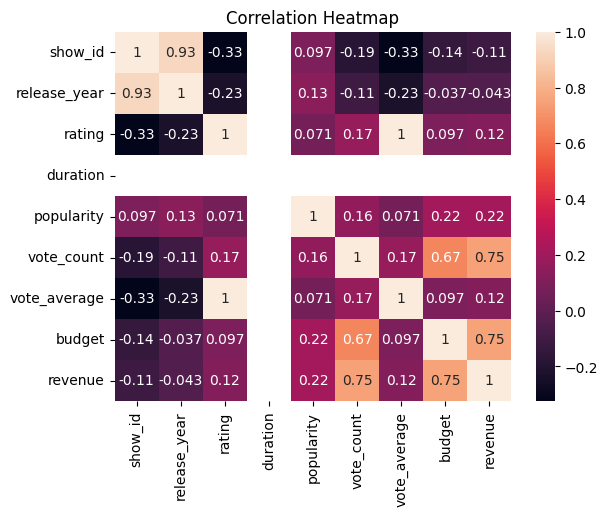

In [ ]:
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Trend Identification

### Yearly Trend

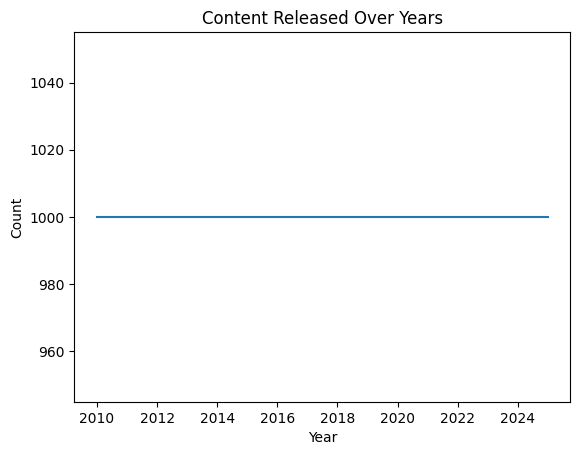

In [ ]:
df['release_year'].value_counts().sort_index().plot(kind='line')

plt.title("Content Released Over Years")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()

### Most Common Ratings

### Top Geners

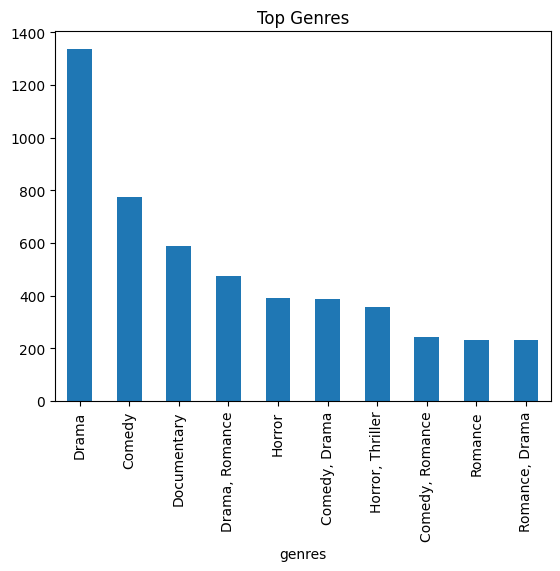

In [ ]:
top_genres = df['genres'].value_counts().head(10)

top_genres.plot(kind='bar')

plt.title("Top Genres")

plt.show()

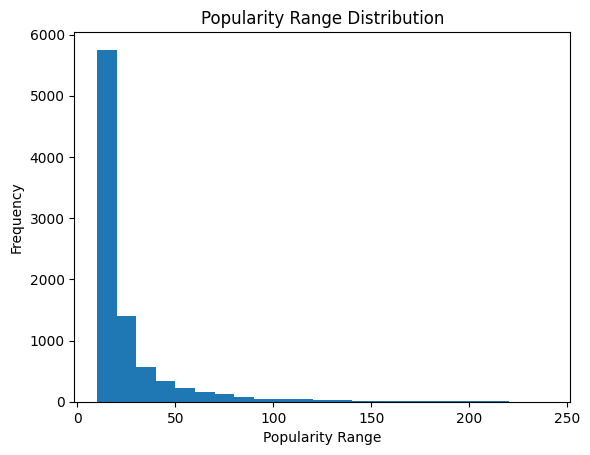

In [ ]:
bins = [10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240]

plt.hist(df['popularity'], bins=bins)

plt.title("Popularity Range Distribution")
plt.xlabel("Popularity Range")
plt.ylabel("Frequency")

plt.show()